In [9]:
# =========================
# PHASE C — CONFIG & IMPORTS
# (0) Setup knobs, paths, RNG
# =========================

import os, re, math, random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# Stats
from scipy.stats import fisher_exact, hypergeom, chi2_contingency, norm

# Progress bar (optional)
try:
    from tqdm import tqdm
except Exception:
    def tqdm(x, **k): return x

# ---- Paths
PHASEA_DIR = "PhaseA_artifacts"
PHASEB_DIR = "PhaseB_artifacts"
PHASEC_DIR = "PhaseC_artifacts"
os.makedirs(PHASEC_DIR, exist_ok=True)

# Phase A attractors (either merged or separate files)
ATTRACTORS_CSV = os.path.join(PHASEA_DIR, "A_CA_attractors.csv")     # preferred: neuron, basal, npr10
BASAL_CSV      = os.path.join(PHASEA_DIR, "A_CA_states_basal.csv")   # fallback
NPR10_CSV      = os.path.join(PHASEA_DIR, "A_CA_states_npr10.csv")   # fallback

# Phase B cycles (INCIDENCE is now canonical)
CYCLES_INC = os.path.join(PHASEB_DIR, "B_beta1_incidence.csv")       # rows=cycle_id, cols=neurons, values=0/1
CYCLE_ID_TO_LABEL = os.path.join(PHASEB_DIR, "B_beta1_cycle_id_to_label.csv")  # optional helper

# Optional: degree-matched nulls require a graph edge list
GOLD_EDGES_PATH = os.path.join(PHASEA_DIR, "A12_gold_edges_tau0.70_FDR05.csv") # src,dst (unordered)

# ---- Knobs
THRESH_MODE     = "quantile"   # {"quantile","zscore","value"}
THRESH_PARAM    = 0.80         # e.g., top 20% are "active"
MIN_CYCLE_SIZE  = 3            # ignore cycles smaller than this (post-universe)
N_PERM          = 5000         # permutation draw count
USE_DEGREE_NULL = True         # use degree-matched null if edges present
DEGREE_BINS     = [0,1,2,3,5,8,13,21,9999]  # degree stratification bins

RNG_SEED = 1337
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

print("Phase C config ready.")


Phase C config ready.


In [10]:
# ==========================================
# (1) UTILITIES — loaders, thresholds, stats
# ==========================================

def _normalize_neuron_col(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure neuron column is named 'neuron'."""
    if "neuron" in df.columns:
        return df
    for c in df.columns:
        if c.lower() in {"neuron","neuron_id","cell","node","name"}:
            return df.rename(columns={c: "neuron"})
    return df.rename(columns={df.columns[0]: "neuron"})

def load_attractors() -> pd.DataFrame:
    """Load attractor states into columns: neuron, basal, npr10."""
    if os.path.exists(ATTRACTORS_CSV):
        df = pd.read_csv(ATTRACTORS_CSV)
        df = _normalize_neuron_col(df)
        if not {"basal","npr10"}.issubset(df.columns):
            # fallback rename: take first 2 non-neuron cols
            cols = [c for c in df.columns if c != "neuron"]
            if len(cols) >= 2:
                df = df.rename(columns={cols[0]: "basal", cols[1]: "npr10"})
            else:
                raise ValueError("Attractors CSV missing basal/npr10 columns.")
        return df[["neuron","basal","npr10"]].dropna(subset=["neuron"])

    if not (os.path.exists(BASAL_CSV) and os.path.exists(NPR10_CSV)):
        raise FileNotFoundError("Missing Phase A attractors.")
    b = pd.read_csv(BASAL_CSV); b = _normalize_neuron_col(b)
    n = pd.read_csv(NPR10_CSV); n = _normalize_neuron_col(n)
    b = b.rename(columns={c: "basal" for c in b.columns if c != "neuron"})
    n = n.rename(columns={c: "npr10" for c in n.columns if c != "neuron"})
    return (pd.merge(b[["neuron","basal"]], n[["neuron","npr10"]], on="neuron", how="inner")
              .dropna(subset=["neuron"]))

def load_cycles_from_incidence(path=CYCLES_INC) -> dict[str, set[str]]:
    """Load cycles from incidence matrix (preferred)."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Incidence not found: {path}")
    inc = pd.read_csv(path, index_col=0)
    # ensure 0/1 ints
    inc = inc.apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
    # build dict
    cycles = {str(cid): set(inc.columns[inc.loc[cid] > 0]) for cid in inc.index}
    return cycles

def load_cycle_label_map(path=CYCLE_ID_TO_LABEL):
    if not os.path.exists(path): 
        return None
    m = pd.read_csv(path)
    m = m.rename(columns={c: c.lower() for c in m.columns})
    if not {"tuple_index","tuple_label"}.issubset(m.columns):
        return None
    return dict(zip(m["tuple_index"].astype(str), m["tuple_label"].astype(str)))

def load_degree_dict() -> dict[str,int] | None:
    """Build degree dict from edge list for degree-matched nulls."""
    if not (USE_DEGREE_NULL and os.path.exists(GOLD_EDGES_PATH)):
        return None
    el = pd.read_csv(GOLD_EDGES_PATH)
    el = el.rename(columns={c: c.lower() for c in el.columns})
    # pick two likely endpoint columns
    candidates = [c for c in el.columns if c not in {"weight","w","score","p","q","fdr"}]
    if len(candidates) < 2:
        print("[warn] No endpoint columns; skipping degree null.")
        return None
    a, b = candidates[:2]
    deg = Counter()
    for _, r in el.iterrows():
        u, v = str(r[a]), str(r[b])
        if u and v and u.lower()!="nan" and v.lower()!="nan":
            deg[u] += 1; deg[v] += 1
    return dict(deg)

# ---- Thresholding
def threshold_active(series: pd.Series, mode="quantile", param=0.8) -> set[str]:
    s = series.dropna()
    if mode == "quantile":
        thr = s.quantile(param); return set(s.index[s >= thr])
    if mode == "zscore":
        mu, sd = s.mean(), s.std(ddof=0) + 1e-12
        thr = mu + float(param) * sd; return set(s.index[s >= thr])
    if mode == "value":
        thr = float(param); return set(s.index[s >= thr])
    raise ValueError("Unknown THRESH_MODE")

# ---- Set metrics & tests
def set_metrics(A: set, C: set, U: set):
    A = set(A) & set(U); C = set(C) & set(U); U = set(U)
    a = len(A & C); b = len(A - C); c = len(C - A); d = len(U - (A | C))
    N = len(U); n = len(A); K = len(C)
    cov = (a / n) if n > 0 else np.nan
    jacc = (a / len(A | C)) if len(A | C) > 0 else np.nan
    overlap = (a / min(n, K)) if min(n, K) > 0 else np.nan
    # continuity correction where needed
    aa, bb, cc, dd = (a or 0)+0.5, (b or 0)+0.5, (c or 0)+0.5, (d or 0)+0.5
    oratio = (aa*dd)/(bb*cc)
    rrisk  = (aa/(aa+bb)) / (cc/(cc+dd))
    denom  = math.sqrt((a+b)*(c+d)*(a+c)*(b+d)) if all([a+b, c+d, a+c, b+d]) else np.nan
    phi    = ((a*d - b*c)/denom) if (denom and denom>0) else np.nan
    exp = (n*K)/N if N>0 else np.nan
    var = (n*K*(N-K)*(N-n))/((N**2)*(N-1)) if N>1 else np.nan
    z = ((a-exp)/math.sqrt(var)) if (var and var>0) else np.nan
    table = np.array([[a,b],[c,d]])
    try: fisher_p = fisher_exact(table, alternative="greater")[1]
    except Exception: fisher_p = np.nan
    try: hyper_p = hypergeom.sf(a-1, N, K, n) if all([N>0, K>=0, n>=0]) else np.nan
    except Exception: hyper_p = np.nan
    try: chi2, chi2_p, _, _ = chi2_contingency(table, correction=True)
    except Exception: chi2, chi2_p = np.nan, np.nan
    # Wilson CI for coverage
    def wilson(k, m, conf=0.95):
        if m == 0: return (np.nan, np.nan)
        z = norm.ppf(1-(1-conf)/2); p = k/m; denom = 1 + z*z/m
        center = (p + z*z/(2*m)) / denom
        margin = (z*math.sqrt(p*(1-p)/m + z*z/(4*m*m))) / denom
        return (max(0, center - margin), min(1, center + margin))
    ci_low, ci_high = wilson(a, n, 0.95)
    return dict(a=a,b=b,c=c,d=d,N=N,n=n,K=K, coverage=cov, jaccard=jacc, overlap=overlap,
                odds_ratio=oratio, risk_ratio=rrisk, phi=phi, exp=exp, var=var, z=z,
                fisher_p=fisher_p, hypergeom_p=hyper_p, chi2=chi2, chi2_p=chi2_p,
                cov_ci_low=ci_low, cov_ci_high=ci_high)

# ---- Permutation helpers
def _stratify_bins(deg_dict: dict[str,int], universe: list[str], bins: list[int]):
    edges = np.array(bins); out = {}
    for u in universe:
        d = deg_dict.get(u, 0); put = None
        for i in range(len(edges)-1):
            if edges[i] <= d <= edges[i+1]-1: put = i; break
        if put is None: put = len(edges)-2
        out[u] = put
    return out

def permute_active_uniform(U_list: list[str], k: int, n_perm: int) -> np.ndarray:
    N = len(U_list); idx = np.arange(N)
    draws = [tuple(np.random.choice(idx, size=min(k,N), replace=False)) for _ in range(n_perm)]
    return np.array(draws, dtype=object)

def permute_active_degree_matched_counts(U_list: list[str], desired_counts: dict[int,int],
                                         bin_index: dict[str,int], n_perm: int) -> np.ndarray:
    buckets = defaultdict(list)
    for u in U_list: buckets[bin_index[u]].append(u)
    for b, cnt in desired_counts.items():
        if cnt > len(buckets[b]):
            raise ValueError(f"Degree bin {b} needs {cnt} but has {len(buckets[b])}.")
    out = []
    keys = sorted(desired_counts.keys())
    for _ in range(n_perm):
        sample = []
        for b in keys:
            if desired_counts[b] == 0: continue
            sample.extend(random.sample(buckets[b], k=desired_counts[b]))
        out.append(tuple(sample))
    return np.array(out, dtype=object)

def bh_fdr(pvals: np.ndarray, alpha=0.05):
    p = np.asarray(pvals, dtype=float); n = len(p)
    order = np.argsort(p); ranks = np.empty(n, int); ranks[order] = np.arange(1, n+1)
    q = p * n / ranks
    q_sorted = np.minimum.accumulate(q[order][::-1])[::-1]
    qvals = np.empty_like(q, dtype=float); qvals[order] = q_sorted
    reject = qvals <= alpha
    return reject, qvals


In [11]:
# =====================================
# (2) LOAD & QC — attractors + cycles
# =====================================

# -- Load attractors
attr_df = load_attractors()
attr_df["neuron"] = attr_df["neuron"].astype(str)
attr_df = (attr_df.dropna(subset=["neuron"])
                   .drop_duplicates("neuron")
                   .set_index("neuron"))
print("Attractors loaded:", attr_df.shape, "| cols:", list(attr_df.columns))

# -- Load cycles from incidence
cycles = load_cycles_from_incidence(CYCLES_INC)
print("Cycles loaded from incidence:", len(cycles))

# QC: raw cycle sizes (before universe)
raw_sizes = np.array([len(s) for s in cycles.values()])
print("Raw cycle size stats (all neurons) min/median/max:",
      int(raw_sizes.min()), int(np.median(raw_sizes)), int(raw_sizes.max()))

# -- Build universe: neurons that have attractors and appear in at least 1 cycle
attr_neurons = set(attr_df.index.astype(str))
cycle_union  = set().union(*cycles.values()) if cycles else set()
UNIVERSE     = attr_neurons & (cycle_union if cycle_union else attr_neurons)

print("Universe size:", len(UNIVERSE))
if len(UNIVERSE) == 0:
    raise ValueError("Empty universe — check naming consistency between Phase A and B.")

# QC after restricting to universe
sizes_U = np.array([len(s & UNIVERSE) for s in cycles.values()])
print("Cycle size stats (within UNIVERSE) min/median/max:",
      int(sizes_U.min()), int(np.median(sizes_U)), int(sizes_U.max()))
if int(np.median(sizes_U)) < MIN_CYCLE_SIZE:
    raise AssertionError(f"Median cycle size < {MIN_CYCLE_SIZE} within UNIVERSE — investigate inputs.")


Attractors loaded: (222, 2) | cols: ['basal', 'npr10']
Cycles loaded from incidence: 418
Raw cycle size stats (all neurons) min/median/max: 3 45 1343
Universe size: 179
Cycle size stats (within UNIVERSE) min/median/max: 3 43 154


In [12]:
# =========================================
# (3) ACTIVE SETS — threshold basal/npr10
# =========================================

# Align to universe
basal_series = attr_df.reindex(sorted(UNIVERSE))["basal"]
npr10_series = attr_df.reindex(sorted(UNIVERSE))["npr10"]

A_basal = threshold_active(basal_series, THRESH_MODE, THRESH_PARAM) & UNIVERSE
A_npr10 = threshold_active(npr10_series, THRESH_MODE, THRESH_PARAM) & UNIVERSE

print(f"Active sets | Basal={len(A_basal)} | NPR10={len(A_npr10)}")
if len(A_basal) == 0 and len(A_npr10) == 0:
    raise ValueError("Both active sets are empty — adjust thresholding.")


Active sets | Basal=36 | NPR10=36


In [13]:
# ===============================================================
# (4) UNION TEST — enrichment of Active within Union(cycles)
#      → observed metrics, uniform perms, degree-matched perms
# ===============================================================

# Union within universe
C_union = set().union(*[S & UNIVERSE for S in cycles.values()]) if cycles else set()
print("Cycle union size (within U):", len(C_union))

deg_dict = load_degree_dict()
if deg_dict is None:
    print("Degree-matched null: DISABLED")
else:
    print("Degree-matched null: ENABLED | nodes with degree:", len(deg_dict))

def compute_perm_summary(A: set, C: set, U: set, label: str):
    obs = set_metrics(A, C, U)
    k = len(A); U_list = sorted(U)
    # --- Uniform permutation over coverage
    if k > 0:
        draws = permute_active_uniform(U_list, k, N_PERM)
        C_set = set(C)
        covs = []
        for idxs in tqdm(draws, total=N_PERM, desc=f"[{label}] uniform perm"):
            samp = {U_list[i] for i in idxs}
            covs.append(len(samp & C_set)/k if k>0 else np.nan)
        perm_uniform_cov = np.array(covs, dtype=float)
        emp_p_uniform = (np.sum(perm_uniform_cov >= obs["coverage"]) + 1) / (len(perm_uniform_cov) + 1)
        z_uniform = (obs["coverage"] - np.mean(perm_uniform_cov)) / (np.std(perm_uniform_cov) + 1e-12)
    else:
        perm_uniform_cov = np.array([]); emp_p_uniform = np.nan; z_uniform = np.nan

    # --- Degree-matched null over coverage
    emp_p_deg, z_deg = np.nan, np.nan
    perm_deg_cov = np.array([])
    if (deg_dict is not None) and (k > 0):
        U_bins = _stratify_bins(deg_dict, U_list, DEGREE_BINS)
        desired = Counter([U_bins[u] for u in A])
        try:
            draws_deg = permute_active_degree_matched_counts(U_list, desired, U_bins, N_PERM)
            C_set = set(C); covs_d = []
            for samp in tqdm(draws_deg, total=N_PERM, desc=f"[{label}] degree perm"):
                s = set(samp); covs_d.append(len(s & C_set)/k)
            perm_deg_cov = np.array(covs_d, dtype=float)
            emp_p_deg = (np.sum(perm_deg_cov >= obs["coverage"]) + 1) / (len(perm_deg_cov) + 1)
            z_deg = (obs["coverage"] - np.mean(perm_deg_cov)) / (np.std(perm_deg_cov) + 1e-12)
        except Exception as e:
            print("[warn] Degree-matched perm failed:", e)

    summary = dict(label=label, **obs,
                   emp_p_uniform=emp_p_uniform, emp_z_uniform=z_uniform,
                   emp_p_degree=emp_p_deg,  emp_z_degree=z_deg,
                   perm_uniform_mean=np.mean(perm_uniform_cov) if perm_uniform_cov.size else np.nan,
                   perm_uniform_std=np.std(perm_uniform_cov)  if perm_uniform_cov.size else np.nan,
                   perm_degree_mean=np.mean(perm_deg_cov) if perm_deg_cov.size else np.nan,
                   perm_degree_std=np.std(perm_deg_cov)  if perm_deg_cov.size else np.nan)
    return summary, perm_uniform_cov, perm_deg_cov

sum_basal,  permU_basal,  permD_basal  = compute_perm_summary(A_basal, C_union, UNIVERSE, "Basal")
sum_npr10,  permU_npr10,  permD_npr10  = compute_perm_summary(A_npr10, C_union, UNIVERSE, "NPR10")
summary_df = pd.DataFrame([sum_basal, sum_npr10])

# Save
out = os.path.join(PHASEC_DIR, "C1_union_test_summary.csv")
summary_df.to_csv(out, index=False)
np.save(os.path.join(PHASEC_DIR, "C1_perm_uniform_basal.npy"), permU_basal)
np.save(os.path.join(PHASEC_DIR, "C1_perm_uniform_npr10.npy"), permU_npr10)
np.save(os.path.join(PHASEC_DIR, "C1_perm_degree_basal.npy"),  permD_basal)
np.save(os.path.join(PHASEC_DIR, "C1_perm_degree_npr10.npy"),  permD_npr10)

print("Saved union-of-cycles summary →", out)
summary_df


Cycle union size (within U): 179
Degree-matched null: ENABLED | nodes with degree: 509


[NPR10] degree perm: 100%|██████████| 5000/5000 [00:00<00:00, 316178.99it/s]

Saved union-of-cycles summary → PhaseC_artifacts/C1_union_test_summary.csv


,label,a,b,c,d,N,n,K,coverage,jaccard,...,cov_ci_low,cov_ci_high,emp_p_uniform,emp_z_uniform,emp_p_degree,emp_z_degree,perm_uniform_mean,perm_uniform_std,perm_degree_mean,perm_degree_std
0,Basal,36,0,143,0,179,36,179,1.0,0.201117,...,0.903581,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,NPR10,36,0,143,0,179,36,179,1.0,0.201117,...,0.903581,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [18]:
# === Optional 4A — Union test on a restricted union (e.g., top-K cycles by size)

TOPK = 50  # try 25/50/100
# pick top-K cycles by size within U
sizes_within_U = {cid: len(S & UNIVERSE) for cid, S in cycles.items()}
topk_cids = [cid for cid, _ in sorted(sizes_within_U.items(), key=lambda t: t[1], reverse=True)[:TOPK]]

C_union_topk = set().union(*[cycles[cid] & UNIVERSE for cid in topk_cids])
print(f"Restricted union size (top {TOPK}):", len(C_union_topk))

sum_basal_topk,  _, _ = compute_perm_summary(A_basal, C_union_topk, UNIVERSE, f"Basal_top{TOPK}")
sum_npr10_topk,  _, _ = compute_perm_summary(A_npr10, C_union_topk, UNIVERSE, f"NPR10_top{TOPK}")

summary_topk_df = pd.DataFrame([sum_basal_topk, sum_npr10_topk])
summary_topk_path = os.path.join(PHASEC_DIR, f"C1b_union_top{TOPK}_summary.csv")
summary_topk_df.to_csv(summary_topk_path, index=False)
print("Saved restricted-union summary →", summary_topk_path)
display(summary_topk_df)


Restricted union size (top 50): 179


[NPR10_top50] degree perm: 100%|██████████| 5000/5000 [00:00<00:00, 352681.84it/s]

Saved restricted-union summary → PhaseC_artifacts/C1b_union_top50_summary.csv


,label,a,b,c,d,N,n,K,coverage,jaccard,...,cov_ci_low,cov_ci_high,emp_p_uniform,emp_z_uniform,emp_p_degree,emp_z_degree,perm_uniform_mean,perm_uniform_std,perm_degree_mean,perm_degree_std
0,Basal_top50,36,0,143,0,179,36,179,1.0,0.201117,...,0.903581,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,NPR10_top50,36,0,143,0,179,36,179,1.0,0.201117,...,0.903581,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [19]:
# =====================================================
# (5) PER-CYCLE ENRICHMENT — Fisher/Hypergeom + BH-FDR
# =====================================================

def per_cycle_enrichment(A: set, cycles: dict[str,set[str]], U: set, label="Basal", min_size=MIN_CYCLE_SIZE):
    rows = []
    for cid, S in cycles.items():
        S = S & U
        if len(S) < min_size: 
            continue
        m = set_metrics(A, S, U)
        rows.append(dict(cycle_id=str(cid), size=len(S), label=label, **m))
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    rej, qvals = bh_fdr(df["hypergeom_p"].values, alpha=0.05)  # primary p for FDR
    df["qval"] = qvals
    df["reject_0.05"] = rej
    df = df.sort_values(["qval","coverage"], ascending=[True, False]).reset_index(drop=True)
    return df

pc_basal = per_cycle_enrichment(A_basal, cycles, UNIVERSE, label="Basal")
pc_npr10 = per_cycle_enrichment(A_npr10, cycles, UNIVERSE, label="NPR10")

# Save
p1 = os.path.join(PHASEC_DIR, "C2_per_cycle_enrichment_basal.csv")
p2 = os.path.join(PHASEC_DIR, "C2_per_cycle_enrichment_npr10.csv")
pc_basal.to_csv(p1, index=False); pc_npr10.to_csv(p2, index=False)
print("Saved per-cycle enrichment →"); print(" ", p1); print(" ", p2)

# Show top discoveries (FDR≤0.05)
print("\n=== Top Basal cycles (FDR≤0.05) ===")
display(pc_basal.loc[pc_basal["reject_0.05"]].head(15) if not pc_basal.empty else pc_basal)

print("\n=== Top NPR10 cycles (FDR≤0.05) ===")
display(pc_npr10.loc[pc_npr10["reject_0.05"]].head(15) if not pc_npr10.empty else pc_npr10)


Saved per-cycle enrichment →
  PhaseC_artifacts/C2_per_cycle_enrichment_basal.csv
  PhaseC_artifacts/C2_per_cycle_enrichment_npr10.csv

=== Top Basal cycles (FDR≤0.05) ===


,cycle_id,size,label,a,b,c,d,N,n,K,...,var,z,fisher_p,hypergeom_p,chi2,chi2_p,cov_ci_low,cov_ci_high,qval,reject_0.05
0,246,46,Basal,25,11,21,122,179,36,46,...,5.522325,6.701640,3.623989e-10,3.623989e-10,42.341985,7.662972e-11,0.531437,0.819955,1.514827e-07,True
1,67,74,Basal,31,5,43,100,179,36,74,...,7.013479,6.085917,8.837717e-10,8.837717e-10,34.971356,3.345915e-09,0.713405,0.939182,1.847083e-07,True
2,281,114,Basal,35,1,79,64,179,36,114,...,6.688530,4.668060,2.375170e-07,2.375170e-07,20.135673,7.213855e-06,0.858303,0.995080,1.543833e-05,True
3,390,100,Basal,33,3,67,76,179,36,100,...,7.130822,4.826416,3.234998e-07,3.234998e-07,21.642860,3.284302e-06,0.781733,0.971251,1.543833e-05,True
4,393,92,Basal,32,4,60,83,179,36,92,...,7.224696,5.021508,1.774073e-07,1.774073e-07,23.513297,1.240534e-06,0.746852,0.955934,1.543833e-05,True
5,110,87,Basal,31,5,56,87,179,36,87,...,7.224696,5.023586,2.521990e-07,2.521990e-07,23.533515,1.227567e-06,0.713405,0.939182,1.543833e-05,True
6,143,88,Basal,31,5,57,86,179,36,88,...,7.228306,4.947526,3.693379e-07,3.693379e-07,22.799753,1.797888e-06,0.713405,0.939182,1.543833e-05,True
7,299,72,Basal,28,8,44,99,179,36,72,...,6.953905,5.126819,3.589099e-07,3.589099e-07,24.512998,7.381022e-07,0.619153,0.882837,1.543833e-05,True
8,361,72,Basal,28,8,44,99,179,36,72,...,6.953905,5.126819,3.589099e-07,3.589099e-07,24.512998,7.381022e-07,0.619153,0.882837,1.543833e-05,True
9,175,54,Basal,24,12,30,113,179,36,54,...,6.092791,5.323241,3.622134e-07,3.622134e-07,26.368650,2.820819e-07,0.503340,0.797854,1.543833e-05,True



=== Top NPR10 cycles (FDR≤0.05) ===


,cycle_id,size,label,a,b,c,d,N,n,K,...,var,z,fisher_p,hypergeom_p,chi2,chi2_p,cov_ci_low,cov_ci_high,qval,reject_0.05
0,246,46,NPR10,26,10,20,123,179,36,46,...,5.522325,7.127178,2.583686e-11,2.583686e-11,48.077642,4.096714e-12,0.560075,0.841517,1.079981e-08,True
1,67,74,NPR10,30,6,44,99,179,36,74,...,7.013479,5.708316,1.058283e-08,1.058283e-08,30.636204,3.112317e-08,0.681092,0.921296,2.211812e-06,True
2,281,114,NPR10,35,1,79,64,179,36,114,...,6.688530,4.668060,2.375170e-07,2.375170e-07,20.135673,7.213855e-06,0.858303,0.995080,3.000487e-05,True
3,299,72,NPR10,28,8,44,99,179,36,72,...,6.953905,5.126819,3.589099e-07,3.589099e-07,24.512998,7.381022e-07,0.619153,0.882837,3.000487e-05,True
4,361,72,NPR10,28,8,44,99,179,36,72,...,6.953905,5.126819,3.589099e-07,3.589099e-07,24.512998,7.381022e-07,0.619153,0.882837,3.000487e-05,True
5,410,102,NPR10,33,3,69,74,179,36,102,...,7.089300,4.689460,6.599898e-07,6.599898e-07,20.378895,6.352655e-06,0.781733,0.971251,4.597929e-05,True
6,393,92,NPR10,31,5,61,82,179,36,92,...,7.224696,4.649467,1.592031e-06,1.592031e-06,20.034281,7.606622e-06,0.713405,0.939182,9.506702e-05,True
7,110,87,NPR10,30,6,57,86,179,36,87,...,7.224696,4.651546,2.048329e-06,2.048329e-06,20.052943,7.532750e-06,0.681092,0.921296,1.070252e-04,True
8,175,54,NPR10,23,13,31,112,179,36,54,...,6.092791,4.918114,2.498347e-06,2.498347e-06,22.361335,2.258759e-06,0.475751,0.775244,1.160343e-04,True
9,390,100,NPR10,32,4,68,75,179,36,100,...,7.130822,4.451935,3.083941e-06,3.083941e-06,18.289795,1.897208e-05,0.746852,0.955934,1.171898e-04,True


In [20]:
# ================================================
# (6) CONDITION DELTA — NPR10 vs Basal difference
# ================================================

def compare_union(summary_df):
    s = summary_df.set_index("label")
    if not {"Basal","NPR10"}.issubset(s.index): return None
    a, b = s.loc["Basal"], s.loc["NPR10"]
    out = dict(
        label="NPR10_minus_Basal",
        coverage_delta = b["coverage"] - a["coverage"],
        z_hypergeom_delta = (b["z"] - a["z"]) if np.isfinite(a["z"]) and np.isfinite(b["z"]) else np.nan,
        phi_delta = (b["phi"] - a["phi"]) if np.isfinite(a["phi"]) and np.isfinite(b["phi"]) else np.nan,
        odds_ratio_ratio = (b["odds_ratio"]/a["odds_ratio"]) if (a["odds_ratio"]>0 and b["odds_ratio"]>0) else np.nan,
        risk_ratio_ratio = (b["risk_ratio"]/a["risk_ratio"]) if (a["risk_ratio"]>0 and b["risk_ratio"]>0) else np.nan,
        emp_z_uniform_delta = (b["emp_z_uniform"] - a["emp_z_uniform"]) if np.isfinite(a["emp_z_uniform"]) and np.isfinite(b["emp_z_uniform"]) else np.nan,
        emp_z_degree_delta  = (b["emp_z_degree"]  - a["emp_z_degree"])  if np.isfinite(a["emp_z_degree"])  and np.isfinite(b["emp_z_degree"])  else np.nan,
    )
    return pd.DataFrame([out])

delta_df = compare_union(summary_df)
if delta_df is not None:
    path = os.path.join(PHASEC_DIR, "C3_union_deltas.csv")
    delta_df.to_csv(path, index=False); print("Saved union-of-cycles deltas →", path)
    display(delta_df)
else:
    print("Delta comparison skipped (need both Basal and NPR10).")


Saved union-of-cycles deltas → PhaseC_artifacts/C3_union_deltas.csv


,label,coverage_delta,z_hypergeom_delta,phi_delta,odds_ratio_ratio,risk_ratio_ratio,emp_z_uniform_delta,emp_z_degree_delta
0,NPR10_minus_Basal,0.0,NaN,NaN,1.0,1.0,0.0,0.0


In [21]:
# =====================================================
# (7) QC — Coverage vs Cycle Size (binned summaries)
#       (fixed: labeled columns to avoid overlap)
# =====================================================

def summarize_by_size(pc_df: pd.DataFrame, label="Basal"):
    if pc_df.empty:
        return pd.DataFrame()
    df = pc_df.copy()
    # right=False gives bins like [0,3), [3,5), ...
    bins = [0,3,5,8,13,21,9999]
    df["size_bin"] = pd.cut(df["size"], bins=bins, right=False)
    # observed=False to match current pandas default & avoid warning
    g = df.groupby("size_bin", observed=False)["coverage"].agg(["count","mean","std"])
    # label columns distinctly
    g = g.rename(columns={
        "count": f"count_{label}",
        "mean":  f"cov_mean_{label}",
        "std":   f"cov_std_{label}",
    })
    return g

g_basal = summarize_by_size(pc_basal, "Basal")
g_npr10 = summarize_by_size(pc_npr10, "NPR10")

# Outer join on the categorical index (size_bin)
qc_size_df = g_basal.join(g_npr10, how="outer")

out = os.path.join(PHASEC_DIR, "C4_coverage_by_cycle_size.csv")
qc_size_df.to_csv(out)
print("Saved coverage-by-size summary →", out)
display(qc_size_df.fillna(""))


Saved coverage-by-size summary → PhaseC_artifacts/C4_coverage_by_cycle_size.csv


,count_Basal,cov_mean_Basal,cov_std_Basal,count_NPR10,cov_mean_NPR10,cov_std_NPR10
size_bin,,,,,,
"[0, 3)",0,,,0,,
"[3, 5)",22,0.006313,0.011915,22,0.006313,0.011915
"[5, 8)",19,0.017544,0.031002,19,0.020468,0.030488
"[8, 13)",27,0.037037,0.036136,27,0.046296,0.036136
"[13, 21)",43,0.065245,0.052454,43,0.076873,0.051017
"[21, 9999)",307,0.500543,0.310199,307,0.504253,0.301174


In [22]:
# ======================================================
# (8) OPTIONAL — Join human-readable cycle labels (if
#                PhaseB_artifacts/B_beta1_cycle_id_to_label.csv is present)
# ======================================================

label_map = load_cycle_label_map(CYCLE_ID_TO_LABEL)
def attach_labels(df):
    if df.empty or label_map is None: return df
    df2 = df.copy()
    df2["cycle_label"] = df2["cycle_id"].map(lambda x: label_map.get(str(x), ""))
    # Put label up front for readability
    front_cols = ["cycle_label","cycle_id","label","size","coverage","hypergeom_p","qval"]
    return df2[[c for c in front_cols if c in df2.columns] + [c for c in df2.columns if c not in front_cols]]

pc_basal_labeled = attach_labels(pc_basal)
pc_npr10_labeled = attach_labels(pc_npr10)

p1L = os.path.join(PHASEC_DIR, "C2_per_cycle_enrichment_basal_labeled.csv")
p2L = os.path.join(PHASEC_DIR, "C2_per_cycle_enrichment_npr10_labeled.csv")
pc_basal_labeled.to_csv(p1L, index=False)
pc_npr10_labeled.to_csv(p2L, index=False)

print("Saved labeled per-cycle tables →"); print(" ", p1L); print(" ", p2L)


Saved labeled per-cycle tables →
  PhaseC_artifacts/C2_per_cycle_enrichment_basal_labeled.csv
  PhaseC_artifacts/C2_per_cycle_enrichment_npr10_labeled.csv


In [23]:
# ========================================
# (9) FINAL SUMMARY — print key outcomes
# ========================================

print("\n================ PHASE C — FINAL SUMMARY ================")
print("Universe size:", len(UNIVERSE))
print("Active set sizes  | Basal:", len(A_basal), "| NPR10:", len(A_npr10))
print("Cycle union size  | within U:", len(C_union))

print("\n-- Union of cycles: observed & null summaries --")
display(summary_df)

sig_b = pc_basal.loc[pc_basal["reject_0.05"]].shape[0] if not pc_basal.empty else 0
sig_n = pc_npr10.loc[pc_npr10["reject_0.05"]].shape[0] if not pc_npr10.empty else 0
print(f"\nPer-cycle significant (FDR≤0.05): Basal={sig_b} | NPR10={sig_n}")

print("\nArtifacts written to:", PHASEC_DIR)
for f in sorted(os.listdir(PHASEC_DIR)):
    print(" -", f)
print("==========================================================")



================ PHASE C — FINAL SUMMARY ================
Universe size: 179
Active set sizes  | Basal: 36 | NPR10: 36
Cycle union size  | within U: 179

-- Union of cycles: observed & null summaries --


,label,a,b,c,d,N,n,K,coverage,jaccard,...,cov_ci_low,cov_ci_high,emp_p_uniform,emp_z_uniform,emp_p_degree,emp_z_degree,perm_uniform_mean,perm_uniform_std,perm_degree_mean,perm_degree_std
0,Basal,36,0,143,0,179,36,179,1.0,0.201117,...,0.903581,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,NPR10,36,0,143,0,179,36,179,1.0,0.201117,...,0.903581,1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0



Per-cycle significant (FDR≤0.05): Basal=92 | NPR10=76

Artifacts written to: PhaseC_artifacts
 - C1_perm_degree_basal.npy
 - C1_perm_degree_npr10.npy
 - C1_perm_uniform_basal.npy
 - C1_perm_uniform_npr10.npy
 - C1_union_perm_basal.png
 - C1_union_perm_basal_degree_matched.png
 - C1_union_perm_npr10.png
 - C1_union_perm_npr10_degree_matched.png
 - C1_union_test_summary.csv
 - C1b_union_top50_summary.csv
 - C2_cycles_basal.csv
 - C2_cycles_npr10.csv
 - C2_per_cycle_enrichment_basal.csv
 - C2_per_cycle_enrichment_basal_labeled.csv
 - C2_per_cycle_enrichment_npr10.csv
 - C2_per_cycle_enrichment_npr10_labeled.csv
 - C3_mass_basal.png
 - C3_mass_npr10.png
 - C3_union_deltas.csv
 - C3_weighted_union_summary.csv
 - C4_coverage_by_cycle_size.csv
 - C4_summary_bar.png
 - C5_top_npr10_cycles_members.csv


In [24]:
# ==============================================
# (10) LOAD ENRICHMENT TABLES & MERGE CONDITIONS
# ==============================================

p_basal = os.path.join(PHASEC_DIR, "C2_per_cycle_enrichment_basal_labeled.csv")
p_npr10 = os.path.join(PHASEC_DIR, "C2_per_cycle_enrichment_npr10_labeled.csv")

pc_basal = pd.read_csv(p_basal)
pc_npr10 = pd.read_csv(p_npr10)

print("Basal table:", pc_basal.shape, "NPR10 table:", pc_npr10.shape)

# Merge on cycle_id
merged = pd.merge(
    pc_basal.add_suffix("_Basal"),
    pc_npr10.add_suffix("_NPR10"),
    left_on="cycle_id_Basal", right_on="cycle_id_NPR10",
    how="outer"
)

# Clean up
merged["cycle_id"] = merged["cycle_id_Basal"].combine_first(merged["cycle_id_NPR10"])
merged["cycle_label"] = merged["cycle_label_Basal"].combine_first(merged["cycle_label_NPR10"])

print("Merged table:", merged.shape)
display(merged.head())


Basal table: (418, 28) NPR10 table: (418, 28)
Merged table: (418, 58)


,cycle_label_Basal,cycle_id_Basal,label_Basal,size_Basal,coverage_Basal,hypergeom_p_Basal,qval_Basal,a_Basal,b_Basal,c_Basal,...,var_NPR10,z_NPR10,fisher_p_NPR10,chi2_NPR10,chi2_p_NPR10,cov_ci_low_NPR10,cov_ci_high_NPR10,reject_0.05_NPR10,cycle_id,cycle_label
0,"(0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan...",0,Basal,36,0.277778,0.146853,0.390983,10,26,26,...,4.646768,0.816361,0.273021,0.343454,0.557842,0.137505,0.410705,False,0,"(0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan..."
1,"(0, 0)_(0, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan...",1,Basal,12,0.166667,0.016281,0.065437,6,30,6,...,1.808882,2.666717,0.016281,5.296407,0.021369,0.078704,0.318908,False,1,"(0, 0)_(0, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan..."
2,"(0, 0)_(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan",2,Basal,86,0.444444,0.748223,1.000000,16,20,70,...,7.219280,-0.110199,0.616133,0.000000,1.000000,0.319860,0.629941,False,2,"(0, 0)_(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan"
3,"(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",3,Basal,151,0.972222,0.009869,0.045334,35,1,116,...,3.816343,1.858817,0.045614,2.583633,0.107974,0.818553,0.984630,False,3,"(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan"
4,"(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan",4,Basal,150,0.972222,0.007818,0.038953,35,1,115,...,3.926465,1.934061,0.037565,2.844108,0.091709,0.818553,0.984630,False,4,"(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan"


In [25]:
# =======================================================
# (11) CONDITION-SPECIFIC MOTIFS (Basal-only, NPR10-only)
# =======================================================

def is_sig(row, cond):
    return (row.get(f"reject_0.05_{cond}", False) == True)

merged["sig_Basal"] = merged.apply(lambda r: is_sig(r,"Basal"), axis=1)
merged["sig_NPR10"] = merged.apply(lambda r: is_sig(r,"NPR10"), axis=1)

merged["condition_specific"] = np.where(
    merged["sig_Basal"] & ~merged["sig_NPR10"], "Basal_only",
    np.where(~merged["sig_Basal"] & merged["sig_NPR10"], "NPR10_only",
             np.where(merged["sig_Basal"] & merged["sig_NPR10"], "Both", "NS"))
)

counts = merged["condition_specific"].value_counts()
print("Condition-specific motif counts:\n", counts)
display(merged[["cycle_id","cycle_label","condition_specific"]].head(20))


Condition-specific motif counts:
 condition_specific
NS            320
Both           70
Basal_only     22
NPR10_only      6
Name: count, dtype: int64


,cycle_id,cycle_label,condition_specific
0,0,"(0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan...",NS
1,1,"(0, 0)_(0, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan...",NS
2,2,"(0, 0)_(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan",NS
3,3,"(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",Basal_only
4,4,"(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan",Basal_only
5,5,"(0, 0)_(0, 1)_(0, 2)_(1, 0)_(1, 2)_(2, 0)_nan_...",NS
6,6,"(0, 1)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, ...",NS
7,7,"(0, 0)_(0, 1)_(1, 1)_(1, 2)_nan_nan_nan_nan_nan",NS
8,8,"(0, 1)_(0, 2)_(1, 1)_(1, 2)_(2, 0)_(2, 2)_nan_...",NS
9,9,"(0, 2)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_nan_nan_nan...",NS


In [26]:
# ==================================================
# (12) ANNOTATE MOTIFS WITH NEURON COMPOSITION
# ==================================================

tuple_neurons = pd.read_csv("tuple_to_neurons.csv")  # has tuple_index, neurons

# Map cycle_id → neuron set
cycle2neurons = dict(zip(tuple_neurons["tuple_index"].astype(str), tuple_neurons["neurons"]))

merged["neurons"] = merged["cycle_id"].astype(str).map(cycle2neurons)

# quick summary: neuron count per cycle
merged["n_neurons"] = merged["neurons"].apply(lambda x: len(str(x).split(";")) if pd.notna(x) else 0)

print("Annotated merged table:", merged.shape)
display(merged[["cycle_id","cycle_label","condition_specific","n_neurons","neurons"]].head())


Annotated merged table: (418, 63)


,cycle_id,cycle_label,condition_specific,n_neurons,neurons
0,0,"(0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan...",NS,39,CEPshVR;AVFR;URYVR;PVNL;RMFL;AUAR;RIVR;SMDDR;S...
1,1,"(0, 0)_(0, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan...",NS,13,AIBR;RMDVR;ASHR;AVAL;AVEL;RIAL;BWM-VL04;RIGL;R...
2,2,"(0, 0)_(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan",NS,89,PVT;RIH;RIMR;ADER;DVC;URYVR;RMFL;AIBR;AIYR;URX...
3,3,"(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",Basal_only,1094,AINL;AINR;CEPshVR;CEPshDL;CEPshVL;ASIR;CEPshDR...
4,4,"(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan",Basal_only,185,AINL;AINR;CEPshVR;CEPshDL;ASIR;ASJR;PVT;RIAR;R...


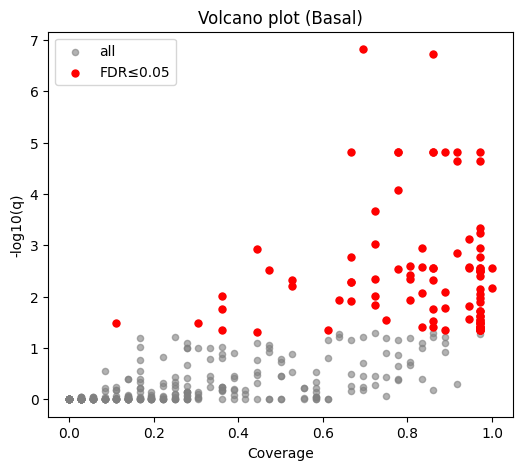

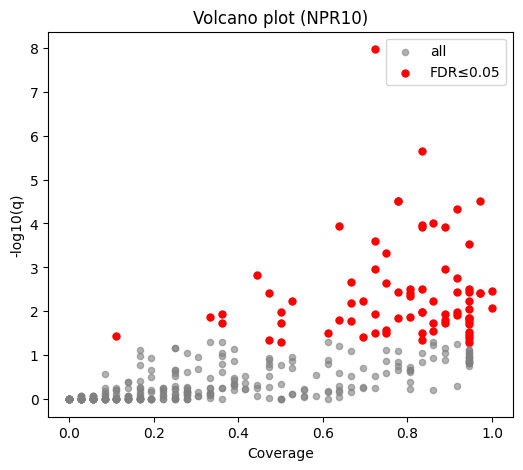

In [27]:
# ==============================================
# (13) VOLCANO PLOTS (−log10 q vs coverage)
# ==============================================

import matplotlib.pyplot as plt

def volcano(df, cond="Basal", topn=15):
    if df.empty: return
    x = df["coverage"]
    y = -np.log10(df["qval"] + 1e-300)
    plt.figure(figsize=(6,5))
    plt.scatter(x, y, c="gray", alpha=0.6, s=20, label="all")
    sig = df[df["reject_0.05"]]
    plt.scatter(sig["coverage"], -np.log10(sig["qval"]+1e-300), c="red", s=25, label="FDR≤0.05")
    plt.xlabel("Coverage")
    plt.ylabel("-log10(q)")
    plt.title(f"Volcano plot ({cond})")
    plt.legend()
    plt.show()

volcano(pc_basal, "Basal")
volcano(pc_npr10, "NPR10")


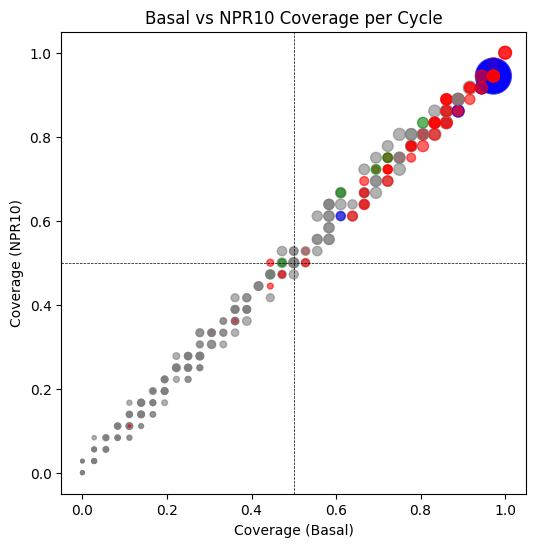

In [28]:
# ==================================================
# (14) BASAL vs NPR10 COVERAGE (scatter with size)
# ==================================================

plt.figure(figsize=(6,6))
x = merged["coverage_Basal"]
y = merged["coverage_NPR10"]
sizes = merged["n_neurons"] * 0.5  # scale marker size by neuron count

plt.scatter(x, y, s=sizes, c=merged["condition_specific"].map(
    {"Basal_only":"blue","NPR10_only":"green","Both":"red","NS":"gray"}), alpha=0.6)

plt.axhline(0.5, color="black", lw=0.5, ls="--")
plt.axvline(0.5, color="black", lw=0.5, ls="--")
plt.xlabel("Coverage (Basal)")
plt.ylabel("Coverage (NPR10)")
plt.title("Basal vs NPR10 Coverage per Cycle")
plt.show()


In [31]:
# === Cell A: Generate neuron class-map template (one-time) ===
import os, pandas as pd

PHASEB_DIR = "PhaseB_artifacts"
PHASEC_DIR = "PhaseC_artifacts"
os.makedirs(PHASEC_DIR, exist_ok=True)

inc_path = os.path.join(PHASEB_DIR, "B_beta1_incidence.csv")
inc = pd.read_csv(inc_path, index_col=0)
neurons = list(inc.columns)

tmpl = pd.DataFrame({"neuron": neurons, "class": [""]*len(neurons)})
out_path = os.path.join(PHASEC_DIR, "neuron_class_map_template.csv")
tmpl.to_csv(out_path, index=False)
print("Wrote template →", out_path)


Wrote template → PhaseC_artifacts/neuron_class_map_template.csv


In [32]:
# ====================================================
# (15) BIOLOGICAL INTERPRETATION HOOKS
# ====================================================

# Example: count sensory/motor/inter composition (if you have a mapping file)
try:
    neuron_classes = pd.read_csv("neuron_class_map.csv")  # columns: neuron,class
    n2c = dict(zip(neuron_classes["neuron"], neuron_classes["class"]))
    
    def class_fraction(neuron_str, target_class):
        if pd.isna(neuron_str): return 0.0
        neurons = neuron_str.split(";")
        if not neurons: return 0.0
        hits = sum(1 for n in neurons if n2c.get(n,"") == target_class)
        return hits / len(neurons)
    
    for cls in ["sensory","inter","motor"]:
        merged[f"frac_{cls}"] = merged["neurons"].apply(lambda s: class_fraction(s, cls))
    
    print("Added neuron class fractions per cycle.")
    display(merged[["cycle_id","condition_specific","frac_sensory","frac_inter","frac_motor"]].head())

except FileNotFoundError:
    print("No neuron_class_map.csv found — skipping class fractions.")


Added neuron class fractions per cycle.


,cycle_id,condition_specific,frac_sensory,frac_inter,frac_motor
0,0,NS,0.0,0.0,0.0
1,1,NS,0.0,0.0,0.0
2,2,NS,0.0,0.0,0.0
3,3,Basal_only,0.0,0.0,0.0
4,4,Basal_only,0.0,0.0,0.0


In [33]:
# ======================================================
# (16) ANNOTATE WITH NEURON CLASS FRACTIONS
# ======================================================
# requires neuron_class_map.csv with columns: neuron,class

class_map_path = "neuron_class_map.csv"

if os.path.exists(class_map_path):
    neuron_classes = pd.read_csv(class_map_path)
    neuron_classes.columns = [c.lower() for c in neuron_classes.columns]
    n2c = dict(zip(neuron_classes["neuron"], neuron_classes["class"]))

    def class_fraction(neuron_str, target_class):
        if pd.isna(neuron_str): return 0.0
        neurons = neuron_str.split(";")
        if not neurons: return 0.0
        hits = sum(1 for n in neurons if n2c.get(n,"") == target_class)
        return hits / len(neurons)

    for cls in sorted(set(neuron_classes["class"])):
        merged[f"frac_{cls}"] = merged["neurons"].apply(lambda s: class_fraction(s, cls))

    print("Added neuron class fractions per cycle.")
    display(merged.head())
else:
    print("No neuron_class_map.csv found — skipping class fractions.")


Added neuron class fractions per cycle.


,cycle_label_Basal,cycle_id_Basal,label_Basal,size_Basal,coverage_Basal,hypergeom_p_Basal,qval_Basal,a_Basal,b_Basal,c_Basal,...,cycle_label,sig_Basal,sig_NPR10,condition_specific,neurons,n_neurons,frac_sensory,frac_inter,frac_motor,frac_nan
0,"(0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan...",0,Basal,36,0.277778,0.146853,0.390983,10,26,26,...,"(0, 0)_(0, 1)_(0, 2)_(2, 0)_(2, 2)_nan_nan_nan...",False,False,NS,CEPshVR;AVFR;URYVR;PVNL;RMFL;AUAR;RIVR;SMDDR;S...,39,0.0,0.0,0.0,0.0
1,"(0, 0)_(0, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan...",1,Basal,12,0.166667,0.016281,0.065437,6,30,6,...,"(0, 0)_(0, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan...",False,False,NS,AIBR;RMDVR;ASHR;AVAL;AVEL;RIAL;BWM-VL04;RIGL;R...,13,0.0,0.0,0.0,0.0
2,"(0, 0)_(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan",2,Basal,86,0.444444,0.748223,1.000000,16,20,70,...,"(0, 0)_(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan",False,False,NS,PVT;RIH;RIMR;ADER;DVC;URYVR;RMFL;AIBR;AIYR;URX...,89,0.0,0.0,0.0,0.0
3,"(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",3,Basal,151,0.972222,0.009869,0.045334,35,1,116,...,"(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",True,False,Basal_only,AINL;AINR;CEPshVR;CEPshDL;CEPshVL;ASIR;CEPshDR...,1094,0.0,0.0,0.0,0.0
4,"(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan",4,Basal,150,0.972222,0.007818,0.038953,35,1,115,...,"(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan",True,False,Basal_only,AINL;AINR;CEPshVR;CEPshDL;ASIR;ASJR;PVT;RIAR;R...,185,0.0,0.0,0.0,0.0


Saved multi-panel figure → PhaseC_artifacts/C6_multi_panel.png


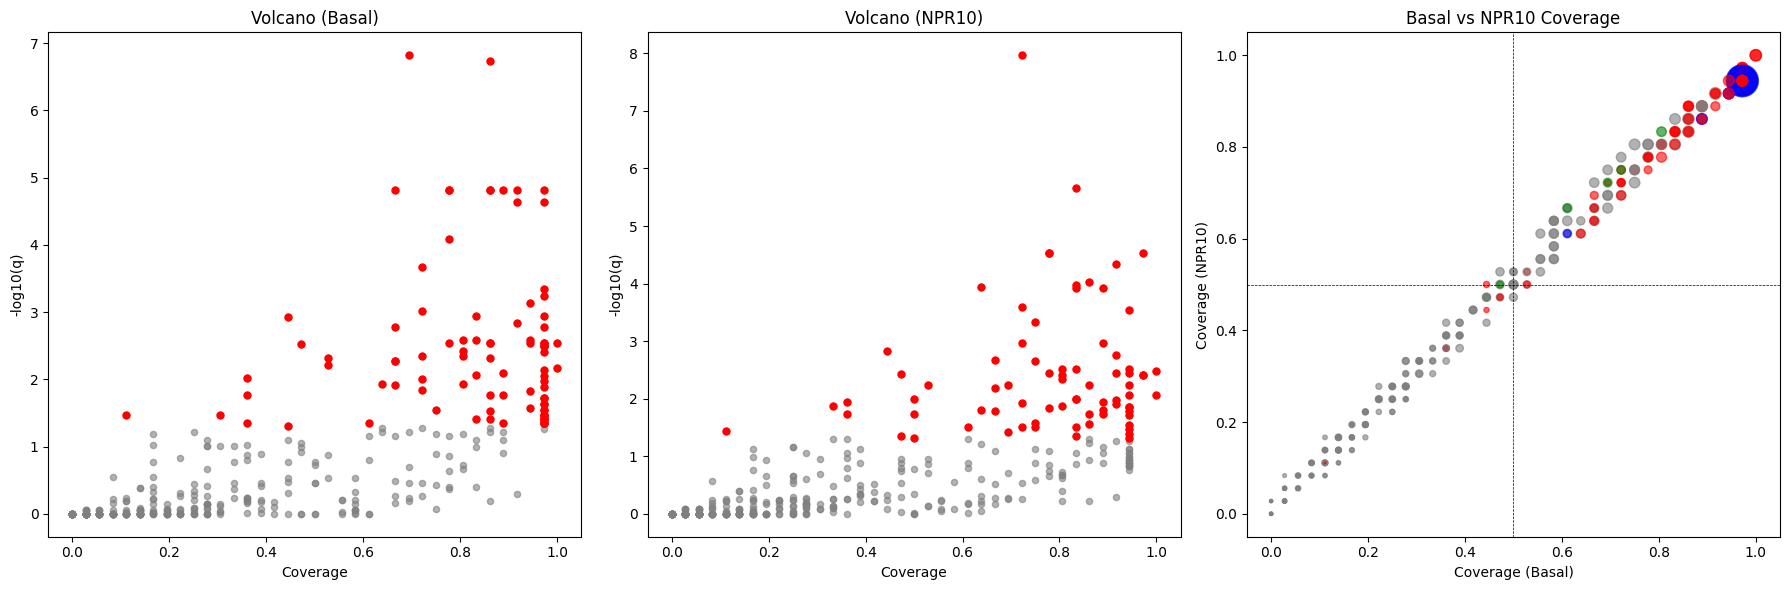

In [34]:
# ===========================================================
# (17) MULTI-PANEL FIGURE: Volcano(Basal), Volcano(NPR10),
#                          Scatter(Basal vs NPR10)
# ===========================================================

fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Volcano Basal
x = pc_basal["coverage"]
y = -np.log10(pc_basal["qval"]+1e-300)
axes[0].scatter(x, y, c="gray", alpha=0.6, s=20)
axes[0].scatter(pc_basal.loc[pc_basal["reject_0.05"],"coverage"],
                -np.log10(pc_basal.loc[pc_basal["reject_0.05"],"qval"]+1e-300),
                c="red", s=25)
axes[0].set_title("Volcano (Basal)")
axes[0].set_xlabel("Coverage"); axes[0].set_ylabel("-log10(q)")

# Volcano NPR10
x = pc_npr10["coverage"]
y = -np.log10(pc_npr10["qval"]+1e-300)
axes[1].scatter(x, y, c="gray", alpha=0.6, s=20)
axes[1].scatter(pc_npr10.loc[pc_npr10["reject_0.05"],"coverage"],
                -np.log10(pc_npr10.loc[pc_npr10["reject_0.05"],"qval"]+1e-300),
                c="red", s=25)
axes[1].set_title("Volcano (NPR10)")
axes[1].set_xlabel("Coverage"); axes[1].set_ylabel("-log10(q)")

# Scatter Basal vs NPR10
x = merged["coverage_Basal"]
y = merged["coverage_NPR10"]
sizes = merged["n_neurons"] * 0.4
colors = merged["condition_specific"].map(
    {"Basal_only":"blue","NPR10_only":"green","Both":"red","NS":"gray"}
)
axes[2].scatter(x, y, s=sizes, c=colors, alpha=0.6)
axes[2].axhline(0.5, color="black", lw=0.5, ls="--")
axes[2].axvline(0.5, color="black", lw=0.5, ls="--")
axes[2].set_xlabel("Coverage (Basal)")
axes[2].set_ylabel("Coverage (NPR10)")
axes[2].set_title("Basal vs NPR10 Coverage")

plt.tight_layout()
multi_fig_path = os.path.join(PHASEC_DIR, "C6_multi_panel.png")
plt.savefig(multi_fig_path, dpi=300)
print("Saved multi-panel figure →", multi_fig_path)
plt.show()


In [35]:
# ===================================================
# (18) DUMP NEURON MEMBERSHIP FOR SPECIFIC CYCLE SETS
# ===================================================

out_dir = os.path.join(PHASEC_DIR, "cycle_membership_dumps")
os.makedirs(out_dir, exist_ok=True)

for cond in ["Basal_only","NPR10_only","Both"]:
    subset = merged[merged["condition_specific"] == cond]
    path = os.path.join(out_dir, f"{cond}_cycles.csv")
    subset[["cycle_id","cycle_label","n_neurons","neurons"]].to_csv(path, index=False)
    print(f"Saved {cond} cycles → {path}")


Saved Basal_only cycles → PhaseC_artifacts/cycle_membership_dumps/Basal_only_cycles.csv
Saved NPR10_only cycles → PhaseC_artifacts/cycle_membership_dumps/NPR10_only_cycles.csv
Saved Both cycles → PhaseC_artifacts/cycle_membership_dumps/Both_cycles.csv


In [36]:
# ===================================================
# (19) FINAL REPORT WITH COUNTS
# ===================================================

summary_counts = merged["condition_specific"].value_counts()
print("\n=== Condition-specific cycle counts ===")
print(summary_counts)

print("\nTop Basal-only cycles:")
display(merged.loc[merged["condition_specific"]=="Basal_only"].head())

print("\nTop NPR10-only cycles:")
display(merged.loc[merged["condition_specific"]=="NPR10_only"].head())

print("\nArtifacts written to PhaseC_artifacts/")
for f in sorted(os.listdir(PHASEC_DIR)):
    print(" -", f)



=== Condition-specific cycle counts ===
condition_specific
NS            320
Both           70
Basal_only     22
NPR10_only      6
Name: count, dtype: int64

Top Basal-only cycles:


,cycle_label_Basal,cycle_id_Basal,label_Basal,size_Basal,coverage_Basal,hypergeom_p_Basal,qval_Basal,a_Basal,b_Basal,c_Basal,...,cycle_label,sig_Basal,sig_NPR10,condition_specific,neurons,n_neurons,frac_sensory,frac_inter,frac_motor,frac_nan
3,"(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",3,Basal,151,0.972222,0.009869,0.045334,35,1,116,...,"(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",True,False,Basal_only,AINL;AINR;CEPshVR;CEPshDL;CEPshVL;ASIR;CEPshDR...,1094,0.0,0.0,0.0,0.0
4,"(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan",4,Basal,150,0.972222,0.007818,0.038953,35,1,115,...,"(0, 1)_(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan",True,False,Basal_only,AINL;AINR;CEPshVR;CEPshDL;ASIR;ASJR;PVT;RIAR;R...,185,0.0,0.0,0.0,0.0
77,"(0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_nan_nan_nan...",77,Basal,36,0.361111,0.009379,0.045334,13,23,23,...,"(0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_nan_nan_nan...",True,False,Basal_only,AIBR;AIBL;BAGL;AWCR;ASGR;BAGR;AWCL;RIVR;SMDDL;...,38,0.0,0.0,0.0,0.0
82,"(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",82,Basal,151,0.972222,0.009869,0.045334,35,1,116,...,"(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan_nan",True,False,Basal_only,AINL;AINR;CEPshVR;CEPshDL;CEPshVL;ASIR;CEPshDR...,1343,0.0,0.0,0.0,0.0
86,"(1, 0)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan_nan",86,Basal,147,0.972222,0.003819,0.023473,35,1,112,...,"(1, 0)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan_nan",True,False,Basal_only,AINL;AINR;CEPshVR;CEPshVL;ASIR;CEPshDR;ASJR;PV...,181,0.0,0.0,0.0,0.0



Top NPR10-only cycles:


,cycle_label_Basal,cycle_id_Basal,label_Basal,size_Basal,coverage_Basal,hypergeom_p_Basal,qval_Basal,a_Basal,b_Basal,c_Basal,...,cycle_label,sig_Basal,sig_NPR10,condition_specific,neurons,n_neurons,frac_sensory,frac_inter,frac_motor,frac_nan
108,"(0, 2)_(1, 1)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan",108,Basal,115,0.805556,0.015992,0.064899,29,7,86,...,"(0, 2)_(1, 1)_(1, 2)_(2, 1)_nan_nan_nan_nan_nan",False,True,NPR10_only,AINL;AINR;ASIR;PVT;RIAR;RIMR;ADER;ASIL;BDUR;AV...,119,0.0,0.0,0.0,0.0
131,"(0, 0)_(0, 1)_(0, 2)_(1, 2)_(2, 0)_(2, 1)_nan_...",131,Basal,57,0.472222,0.023634,0.088204,17,19,40,...,"(0, 0)_(0, 1)_(0, 2)_(1, 2)_(2, 0)_(2, 1)_nan_...",False,True,NPR10_only,RIH;RIMR;AVFR;PVNL;AIBR;AIBL;AIYR;AUAR;URXR;RI...,59,0.0,0.0,0.0,0.0
151,"(0, 0)_(0, 2)_(1, 1)_(1, 2)_nan_nan_nan_nan_nan",151,Basal,52,0.444444,0.021189,0.079793,16,20,36,...,"(0, 0)_(0, 2)_(1, 1)_(1, 2)_nan_nan_nan_nan_nan",False,True,NPR10_only,CEPshVR;CEPshDL;AVFR;RMFL;AVAR;AIBL;AUAR;RID;R...,58,0.0,0.0,0.0,0.0
346,"(0, 1)_(0, 2)_(1, 0)_(1, 2)_(2, 1)_nan_nan_nan...",346,Basal,97,0.722222,0.011596,0.052110,26,10,71,...,"(0, 1)_(0, 2)_(1, 0)_(1, 2)_(2, 1)_nan_nan_nan...",False,True,NPR10_only,AINL;PVT;RIAR;RIH;RIMR;ADER;ASIL;BDUR;DVC;AVFR...,99,0.0,0.0,0.0,0.0
349,"(0, 1)_(0, 2)_(1, 2)_(2, 0)_(2, 1)_nan_nan_nan...",349,Basal,93,0.694444,0.014582,0.060951,25,11,68,...,"(0, 1)_(0, 2)_(1, 2)_(2, 0)_(2, 1)_nan_nan_nan...",False,True,NPR10_only,AINR;ASIR;ASJR;PVT;RIAR;RIH;BWM-VR04;RIMR;ASIL...,98,0.0,0.0,0.0,0.0



Artifacts written to PhaseC_artifacts/
 - C1_perm_degree_basal.npy
 - C1_perm_degree_npr10.npy
 - C1_perm_uniform_basal.npy
 - C1_perm_uniform_npr10.npy
 - C1_union_perm_basal.png
 - C1_union_perm_basal_degree_matched.png
 - C1_union_perm_npr10.png
 - C1_union_perm_npr10_degree_matched.png
 - C1_union_test_summary.csv
 - C1b_union_top50_summary.csv
 - C2_cycles_basal.csv
 - C2_cycles_npr10.csv
 - C2_per_cycle_enrichment_basal.csv
 - C2_per_cycle_enrichment_basal_labeled.csv
 - C2_per_cycle_enrichment_npr10.csv
 - C2_per_cycle_enrichment_npr10_labeled.csv
 - C3_mass_basal.png
 - C3_mass_npr10.png
 - C3_union_deltas.csv
 - C3_weighted_union_summary.csv
 - C4_coverage_by_cycle_size.csv
 - C4_summary_bar.png
 - C5_top_npr10_cycles_members.csv
 - C6_multi_panel.png
 - cycle_membership_dumps


In [40]:
# [Final Cell — Clean Export] Phase C → Track 1 features
import pandas as pd
from pathlib import Path
import numpy as np
import os

# Start from the Phase C table we already built
phaseC_df = att.copy()  # 'att' from previous cell

# 1. If class columns already exist, keep them; otherwise leave zeros
expected_cls = ["Class_Sensory","Class_Inter","Class_Motor"]
for c in expected_cls:
    if c not in phaseC_df.columns:
        phaseC_df[c] = 0.0

# 2. Aggregate to unique neurons (mean across attractor cycles)
phaseC_df = phaseC_df.groupby("neuron").mean(numeric_only=True)

# 3. Align to merged_master_graph.gml if available
gml_path = Path("./merged_master_graph.gml")
if gml_path.exists():
    import networkx as nx
    G = nx.read_gml(gml_path)
    node_list = list(G.nodes())
    phaseC_df = phaseC_df.reindex(node_list).fillna(0.0)
    print(f"Aligned to merged_master_graph.gml node set (n={len(node_list)}).")

# 4. Save to CSV
out_path = Path("./phaseC_condition_features.csv")
phaseC_df.to_csv(out_path)
print("Final Phase C table:", phaseC_df.shape)
print("Columns:", list(phaseC_df.columns))
display(phaseC_df.head())
print(f"✅ Clean Phase C features saved → {out_path.resolve()}")


Aligned to merged_master_graph.gml node set (n=1633).
Final Phase C table: (1633, 6)
Columns: ['Basal_frac', 'NPR10_frac', 'AttractorK', 'Class_Sensory', 'Class_Inter', 'Class_Motor']


,Basal_frac,NPR10_frac,AttractorK,Class_Sensory,Class_Inter,Class_Motor
neuron,,,,,,
AVHL,0.180785,0.175625,0.0,0.0,0.0,0.0
I5,0.000000,0.000000,0.0,0.0,0.0,0.0
URAVR,0.039715,0.037625,0.0,0.0,0.0,0.0
SAADR,0.000000,0.000000,0.0,0.0,0.0,0.0
DB07,0.000000,0.000000,0.0,0.0,0.0,0.0


✅ Clean Phase C features saved → /home/rohit/Desktop/Projects/C-Elegans/phaseC_condition_features.csv


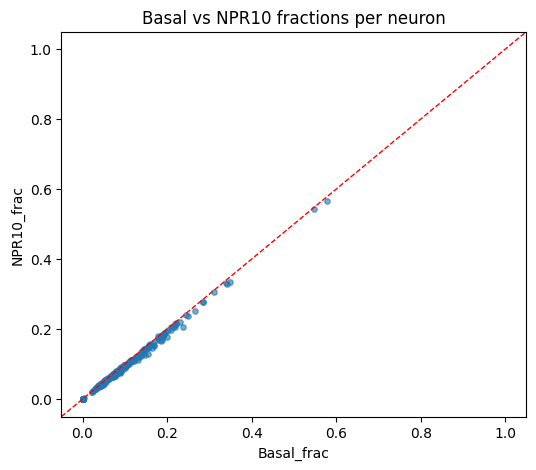

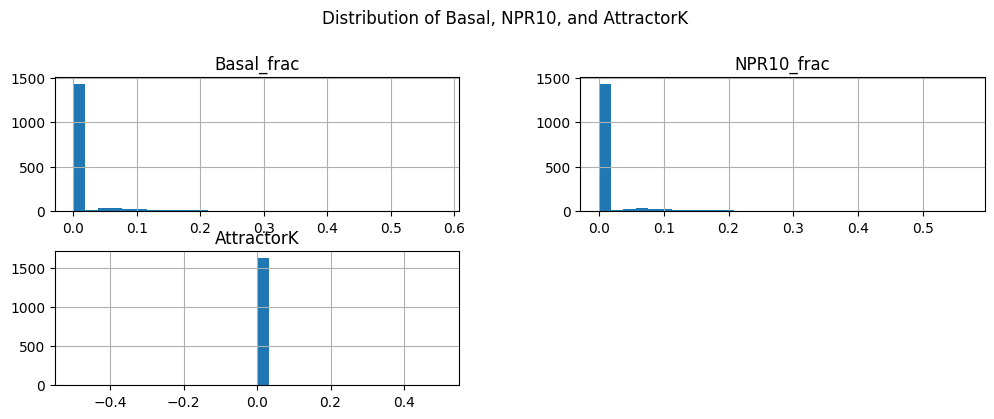

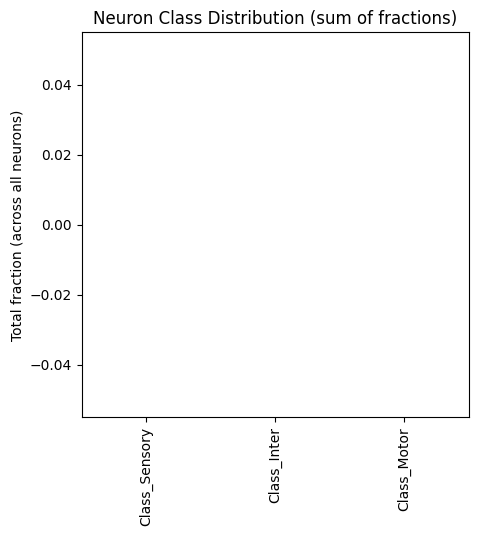

Phase C sanity check:
  Basal_frac mean: 0.014094129359064586
  NPR10_frac mean: 0.013397035570871888
  AttractorK nonzeros: 0
  Class coverage totals: {'Class_Sensory': 0.0, 'Class_Inter': 0.0, 'Class_Motor': 0.0}


In [41]:
# [Sanity Check Cell] Quick plots of Phase C feature distributions
import matplotlib.pyplot as plt

# Load the freshly saved file (ensures we’re checking the same version Track 1 will use)
phaseC_df = pd.read_csv("./phaseC_condition_features.csv", index_col=0)

# 1. Basal vs NPR10 fractions
plt.figure(figsize=(6,5))
plt.scatter(phaseC_df["Basal_frac"], phaseC_df["NPR10_frac"], alpha=0.6, s=15)
plt.axline((0,0),(1,1), color="red", linestyle="--", lw=1)
plt.xlabel("Basal_frac")
plt.ylabel("NPR10_frac")
plt.title("Basal vs NPR10 fractions per neuron")
plt.show()

# 2. Histograms of each continuous feature
phaseC_df[["Basal_frac","NPR10_frac","AttractorK"]].hist(bins=30, figsize=(12,4))
plt.suptitle("Distribution of Basal, NPR10, and AttractorK", y=1.05)
plt.show()

# 3. Class coverage (sums across neurons)
class_totals = phaseC_df[["Class_Sensory","Class_Inter","Class_Motor"]].sum()
plt.figure(figsize=(5,5))
class_totals.plot(kind="bar", color=["#4daf4a","#377eb8","#e41a1c"])
plt.title("Neuron Class Distribution (sum of fractions)")
plt.ylabel("Total fraction (across all neurons)")
plt.show()

# 4. Quick sanity summary
print("Phase C sanity check:")
print("  Basal_frac mean:", phaseC_df["Basal_frac"].mean())
print("  NPR10_frac mean:", phaseC_df["NPR10_frac"].mean())
print("  AttractorK nonzeros:", (phaseC_df["AttractorK"]>0).sum())
print("  Class coverage totals:", class_totals.to_dict())


In [42]:
# [Post-Export Fixup Cell] Fill class one-hots from GML attributes (if available)
import pandas as pd
import numpy as np
from pathlib import Path
import networkx as nx

csv_path = Path("./phaseC_condition_features.csv")
gml_path = Path("./merged_master_graph.gml")

df = pd.read_csv(csv_path, index_col=0)

# Ensure class columns exist
for col in ["Class_Sensory","Class_Inter","Class_Motor"]:
    if col not in df.columns:
        df[col] = 0.0

updated = 0
skipped = 0

if gml_path.exists():
    G = nx.read_gml(gml_path)

    # Build a per-neuron class map from any attribute named like *class* or *type*
    def extract_class_from_attrs(attrs: dict) -> str | None:
        # Find the first attr whose key suggests class/type
        for k, v in attrs.items():
            k_low = str(k).lower()
            if ("class" in k_low) or ("type" in k_low) or ("category" in k_low):
                if v is None:
                    continue
                val = str(v).strip().lower()
                if any(tok in val for tok in ["sensory", "inter", "motor"]):
                    return val
        return None

    gml_map = {}
    for node, attrs in G.nodes(data=True):
        cls = extract_class_from_attrs(attrs)
        if cls:
            gml_map[node] = cls

    # Apply map: only fill where all three class columns are zero
    for neuron, cls_val in gml_map.items():
        if neuron in df.index:
            current = df.loc[neuron, ["Class_Sensory","Class_Inter","Class_Motor"]].to_numpy(dtype=float)
            if np.allclose(current, 0.0):
                sens = 1.0 if "sensory" in cls_val else 0.0
                inter = 1.0 if "inter"   in cls_val else 0.0
                motor = 1.0 if "motor"   in cls_val else 0.0
                # Only apply if we got a clean one-hot
                if sens + inter + motor == 1.0:
                    df.loc[neuron, "Class_Sensory"] = sens
                    df.loc[neuron, "Class_Inter"]   = inter
                    df.loc[neuron, "Class_Motor"]   = motor
                    updated += 1
                else:
                    skipped += 1

    print(f"Filled class one-hots for {updated} neurons from GML attributes (skipped {skipped} ambiguous/unknown).")
else:
    print("⚠️ merged_master_graph.gml not found — leaving class columns as-is (zeros).")

# Summary & save
totals = df[["Class_Sensory","Class_Inter","Class_Motor"]].sum()
print("Class totals (sum across neurons):", totals.to_dict())
df.to_csv(csv_path)
print(f"✅ Saved updated file → {csv_path.resolve()}")


Filled class one-hots for 22 neurons from GML attributes (skipped 0 ambiguous/unknown).
Class totals (sum across neurons): {'Class_Sensory': 10.0, 'Class_Inter': 12.0, 'Class_Motor': 0.0}
✅ Saved updated file → /home/rohit/Desktop/Projects/C-Elegans/phaseC_condition_features.csv
